READ THROUGH ENTIRE CODE, MAKE SURE EVERYTHING CHECKS OUT
- Do markdown test explainations make sense?
- Markdown text aligns with what's actually in the code?

# CNN-LSTM — IMU Gym Exercise Recognition (Cross-Dataset)

**Adapted for:**
- IMU-only input (6 channels: accel + gyro) at **20 Hz**
- **2 classes**: Arm Curl (parent=1) vs Bench Press (parent=5)
- **LOSO** (Leave-One-Subject-Out) cross-validation by participant
- Training on only online datasets (LEAN & MyoGym), and testing on our collected data

**Training data** (`golden_dataset_v10_20Hz.csv`):
- `dataset == 'lean'`   -> (1,3) Arm Curl    -> label 0
- `dataset == 'myogym'` -> (5,5) Bench Press -> label 1

**Test data** (`OurData_v5_scaled_20Hz.csv`) -- ALL 10 exercise pairs:
- Arm Curl:    (1,1) (1,2) (1,3) (1,4)
- Bench Press: (5,5) (5,6) (5,7) (5,8) (5,9) (5,10)

---
## 0. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data --
DATA_PATH     = "data/golden_dataset_v10_20Hz.csv"
OUR_DATA_PATH = "data/OurData_v5_scaled_20Hz.csv"

# Source labels in golden_dataset used for training
TRAIN_SOURCES = ["lean", "myogym"]

# -- Training pairs: (parent, child) --
# lean   -> (1,3) Arm Curl     -> label 0
# myogym -> (5,5) Bench Press  -> label 1
KEEP_PAIRS = [(1, 3), (5, 5)]

# -- All 10 test pairs from OurData --
TEST_PAIRS = [(1,1),(1,2),(1,3),(1,4),(5,5),(5,6),(5,7),(5,8),(5,9),(5,10)]

# -- Two parent classes --
PARENT_CLASSES = {1: "Arm Curl", 5: "Bench Press"}

# Maps parent value -> model label (must be 0-indexed for CrossEntropyLoss)
LABEL_MAP = {1: 0, 5: 1}
NUM_CLASSES = len(LABEL_MAP)  # 2

# Integer encoding of each test pair for per-exercise reporting
PAIR_TO_INT = {pair: idx for idx, pair in enumerate(TEST_PAIRS)}
INT_TO_PAIR = {idx: pair for pair, idx in PAIR_TO_INT.items()}

# -- Preprocessing --
SAMPLING_RATE    = 20       # Hz
NUM_IMU_CHANNELS = 6        # accel_xyz + gyro_xyz
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap

# -- Training --
EPOCHS        = 75
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
PATIENCE      = 15

# -- IMU column names (must match your CSV) --
IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]


---
## 1. Mount Google Drive & Load Data

In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [4]:
import os

BASE_PATH          = "/content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
FULL_DATA_PATH     = os.path.join(BASE_PATH, DATA_PATH)
FULL_OUR_DATA_PATH = os.path.join(BASE_PATH, OUR_DATA_PATH)

print(f"Loading: {FULL_DATA_PATH}")
df_full = pd.read_csv(FULL_DATA_PATH)
print(f"Full dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Columns: {list(df_full.columns)}")

# Keep only lean + myogym sources
df_train_src = df_full[df_full["dataset"].str.lower().isin(TRAIN_SOURCES)].copy().reset_index(drop=True)

print(f"\nSource counts in full dataset:")
print(df_full["dataset"].value_counts().to_string())
print(f"\nTraining source rows (lean + myogym): {len(df_train_src):,}")
df_full.head()


Loading: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/golden_dataset_v10_20Hz.csv
Full dataset: 24,788 rows, 12 columns
Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID', 'dataset']

Source counts in full dataset:
dataset
ourdata    9891
lean       9668
myogym     5229

Training source rows (lean + myogym): 14,897


,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID,dataset
0,-0.607620,0.260122,-0.244656,-3.580708,61.459589,-11.303101,5,5,18,1,38,ourdata
1,0.938619,-0.286055,-0.031800,-18.836250,-37.515571,16.490179,5,5,18,1,38,ourdata
2,-0.383179,0.059054,-0.093280,-33.899180,-2.453326,0.954961,5,5,18,1,38,ourdata
3,0.154184,0.109962,0.244019,-1.578370,8.389933,3.827915,5,5,18,1,38,ourdata
4,-0.075512,-0.099518,-0.049661,-3.277634,17.204920,8.430352,5,5,18,1,38,ourdata


---
## 2. Filter & Label Training Data

Keep only the two target pairs from the lean and myogym sources:
- `(1,3)` from `lean`   -> Arm Curl    -> label 0
- `(5,5)` from `myogym` -> Bench Press -> label 1

Sanity-check that the pair/dataset mapping matches expectations.


In [5]:
# Filter to target (parent, child) pairs within the training sources
pair_mask_train = pd.Series(False, index=df_train_src.index)
for p, c in KEEP_PAIRS:
    pair_mask_train |= (df_train_src["parent"] == p) & (df_train_src["child"] == c)

df_filtered = df_train_src[pair_mask_train].copy().reset_index(drop=True)
df_filtered["label"] = df_filtered["parent"].map(LABEL_MAP)

# Sanity check: verify dataset/pair alignment
lean_pairs   = set(zip(df_filtered[df_filtered["dataset"]=="lean"]["parent"],
                       df_filtered[df_filtered["dataset"]=="lean"]["child"]))
myogym_pairs = set(zip(df_filtered[df_filtered["dataset"]=="myogym"]["parent"],
                       df_filtered[df_filtered["dataset"]=="myogym"]["child"]))
print(f"'lean'   pairs: {lean_pairs}   (expected: {chr(123)}(1, 3){chr(125)})")
print(f"'myogym' pairs: {myogym_pairs} (expected: {chr(123)}(5, 5){chr(125)})")
assert lean_pairs == {(1, 3)},   "Unexpected pairs in lean!"
assert myogym_pairs == {(5, 5)}, "Unexpected pairs in myogym!"
print("Pair assertions passed.\n")

print(f"Training set (lean + myogym, filtered): {len(df_filtered):,} rows")
print(f"\nClass distribution (train):")
for (p, c), pair_label in zip(KEEP_PAIRS, LABEL_MAP.values()):
    count = (df_filtered["label"] == pair_label).sum()
    print(f"  parent={p}, child={c}  ->  label {pair_label}  ->  {count:,} rows")
print(f"\nParticipants (train): {sorted(df_filtered['participant'].unique())}")
print(f"Unique IDs (train):   {df_filtered['ID'].nunique()}")


'lean'   pairs: {(1, 3)}   (expected: {(1, 3)})
'myogym' pairs: {(5, 5)} (expected: {(5, 5)})
Pair assertions passed.

Training set (lean + myogym, filtered): 14,897 rows

Class distribution (train):
  parent=1, child=3  ->  label 0  ->  9,668 rows
  parent=5, child=5  ->  label 1  ->  5,229 rows

Participants (train): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Unique IDs (train):   23


In [6]:
# Quick sanity check: show a sample ID's label sequence
sample_id = df_filtered["ID"].unique()[0]
sample = df_filtered[df_filtered["ID"] == sample_id]
print(f"ID {sample_id}: {len(sample)} rows")
print(f"  Label sequence: {sample['label'].unique()} (0=Arm Curl, 1=Bench Press)")
print(f"  Participant: {sample['participant'].iloc[0]}")
print(f"  Dataset: {sample['dataset'].unique()}")
print(f"  Parent values: {sample['parent'].unique()}")
print(f"  Child values:  {sample['child'].unique()}")


ID 5: 629 rows
  Label sequence: [1] (0=Arm Curl, 1=Bench Press)
  Participant: 5
  Dataset: ['myogym']
  Parent values: [5]
  Child values:  [5]


---
## 3. Preprocessing

**Denoising at 20 Hz:** The paper used a bandpass filter of 1–20 Hz at 50 Hz sampling. At 20 Hz, the Nyquist frequency is only 10 Hz, so a 1–20 Hz band is impossible. Instead we use a **1–9 Hz bandpass**, which:
- Removes DC drift and slow offset changes below 1 Hz
- Keeps the core human motion band (~1–8 Hz for exercise movements)
- Stays safely below the 10 Hz Nyquist limit

**Unit conversion:** Acceleration is converted from G's to m/s² (×9.81) before denoising.

**Segmentation** is done **per ID** to avoid windows that span across different recordings.

In [7]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data at 20 Hz.

    Steps:
      1. Denoise   — 6th-order zero-phase Butterworth bandpass (1–9 Hz)
      2. Normalize  — Per-channel min–max scaling to [0, 1]
      3. Segment    — Sliding window per ID with majority-vote labels
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=1.0, highcut=9.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)  # 40 samples
        self.step_size = int(self.window_size * (1.0 - overlap)) # 20 samples
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {0.5 * self.fs} Hz")
        print(f"  Bandpass:       {self.lowcut}–{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        """
        6th-order zero-phase Butterworth bandpass (1–9 Hz), per channel.
        At 20 Hz sampling, Nyquist = 10 Hz, so 9 Hz is the safe upper bound.
        """
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            print("  Warning: filter band invalid, skipping denoise")
            return data.copy()
        b, a = butter(self.filter_order, [lo, hi], btype="band")
        out = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]  # too short to filter
        return out

    def fit_normalize(self, data):
        """Fit per-channel min/max from training data, return normalized."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data):
        """Apply previously fitted min–max (for validation data)."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data):
        denom = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    def segment_single(self, data, labels):
        """Sliding window on a single continuous sequence."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant"):
        """
        Segment per ID to avoid windows spanning different recordings.

        Returns:
            X:            (N, window_size, channels)
            y:            (N,) integer labels
            participants: (N,) participant ID per window (for LOSO)
        """
        all_X, all_y, all_participants = [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]

            if len(imu) < self.window_size:
                continue  # skip IDs shorter than one window

            windows, window_labels = self.segment_single(imu, labels)
            all_X.extend(windows)
            all_y.extend(window_labels)
            all_participants.extend([participant] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_participants))

In [8]:
# Run preprocessing
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=1.0,
    highcut=9.0,
)

# -- Training data (lean + myogym) --
print("\n[Train] Converting acceleration from G's to m/s2...")
accel_cols = ["x_accel", "y_accel", "z_accel"]
df_filtered[accel_cols] = df_filtered[accel_cols] * 9.81

print("[Train] Denoising...")
imu_raw = df_filtered[IMU_COLS].values
imu_denoised = pp.denoise(imu_raw)

df_processed = df_filtered.copy()
df_processed[IMU_COLS] = imu_denoised

print("[Train] Normalizing (fit on training data)...")
imu_normalized = pp.fit_normalize(df_processed[IMU_COLS].values)
df_processed[IMU_COLS] = imu_normalized
print(f"  Train value range: [{df_processed[IMU_COLS].min().min():.4f}, "
      f"{df_processed[IMU_COLS].max().max():.4f}]")

print("[Train] Segmenting per ID...")
X, y, participants = pp.segment_by_id(df_processed, IMU_COLS)

print(f"\nTraining windows:")
print(f"  X: {X.shape}  (windows x timesteps x channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes)")
print(f"  Participants: {np.unique(participants)}")
print(f"\nWindows per class:")
for label_val, label_name in zip([0, 1], ["Arm Curl (1,3)", "Bench Press (5,5)"]):
    print(f"  Label {label_val} ({label_name}): {(y == label_val).sum()}")


Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       1.0–9.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

[Train] Converting acceleration from G's to m/s2...
[Train] Denoising...
[Train] Normalizing (fit on training data)...
  Train value range: [0.0000, 1.0000]
[Train] Segmenting per ID...

Training windows:
  X: (711, 40, 6)  (windows x timesteps x channels)
  y: (711,)  (2 classes)
  Participants: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]

Windows per class:
  Label 0 (Arm Curl (1,3)): 464
  Label 1 (Bench Press (5,5)): 247


---
## 4. Dev Set

All windows from the lean + myogym sources form the **dev set** used for LOSO
cross-validation and hyperparameter tuning.

The **test set** (`OurData_v5_scaled_20Hz.csv`) is completely held out and is
loaded in Section 10. It is never seen during LOSO or hyperparameter selection.


In [9]:
# All preprocessed training windows are the dev set
X_dev, y_dev, participants_dev = X, y, participants

print(f"Dev set (lean + myogym):  {X_dev.shape[0]:,} windows")
print(f"  Participants: {sorted(np.unique(participants_dev))}")

print(f"\nDev class distribution:")
for lv, ln in zip([0, 1], ["Arm Curl (1,3)", "Bench Press (5,5)"]):
    print(f"  Label {lv} ({ln}): {(y_dev == lv).sum()}")


Dev set (lean + myogym):  711 windows
  Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

Dev class distribution:
  Label 0 (Arm Curl (1,3)): 464
  Label 1 (Bench Press (5,5)): 247


---
## 5. Model — CNN-LSTM (Section 3.4)

In [10]:
class ResBiGRUBlock(nn.Module):
    """
    Residual Bidirectional GRU block (Section 3.4.2, Figure 6, Eqs. 4-6).

    Each stacked layer:
        h = BiGRU(x)           # forward + backward GRU, concatenated
        r = Linear(x)          # project input to match h's dimension
        x = LayerNorm(r + h)   # residual connection + normalization
    """

    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)
            r = blk["proj"](x)
            x = blk["ln"](r + h)
        return x

In [11]:
class CNNResBiGRU(nn.Module):
    """
    CNN-ResBiGRU model (Section 3.4, Figure 5).

    Input:  (batch, seq_len, in_channels)
    Output: (batch, num_classes) — raw logits
    """

    def __init__(self, in_channels=6, num_classes=2,
                 conv_filters=(64, 128, 256, 512), kernel=3, pool=2,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128):
        super().__init__()

        # 4 × Conv Blocks (Section 3.4.1)
        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.MaxPool1d(pool),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        # Residual BiGRU (Section 3.4.2)
        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)         # (B, T, C) → (B, C, T) for Conv1d
        x = self.conv(x)
        x = x.permute(0, 2, 1)         # back to (B, T', C') for GRU
        x = self.resbigru(x)
        x = x.mean(dim=1)              # global average pooling
        return self.head(x)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)

        # CNN
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (batch, channels, seq_len//4)
        x = F.relu(self.bn3(self.conv3(x)))

        # Prepare for LSTM
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq_len_reduced, hidden_dim)
        out = lstm_out[:, -1, :]    # last hidden state

        # Classifier
        out = self.fc(out)
        return out

In [13]:
# Quick architecture check
test_model = CNN_LSTM(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
test_output = test_model(test_input)

n_params = sum(p.numel() for p in test_model.parameters())
print(f"Input shape:  {tuple(test_input.shape)}")
print(f"Output shape: {tuple(test_output.shape)}")
print(f"Parameters:   {n_params:,}")

del test_model, test_input, test_output

Input shape:  (2, 40, 6)
Output shape: (2, 2)
Parameters:   142,786


---
## 6. Hyperparameter Search via LOSO

**Random search** over hyperparameter configurations. Each candidate runs a full
Leave-One-Subject-Out sweep on the dev participants. The configuration with the
best mean F1 is selected for the final model.

### How LOSO Cross-Validation Works (and Why We're Using It This Way)

We want a reliable estimate of how well our model will perform on people it has never seen before. The simplest way to measure this would be to split our participants into a training group and a validation group — but that gives us exactly one number, and that number depends heavily on which participants happened to end up in which group. One unlucky split could make a good model look bad, or vice versa.

**Leave-One-Subject-Out (LOSO)** solves this by running every possible one-participant holdout. If we have 4 dev participants, we train 4 separate models: the first holds out participant A and trains on B, C, D. The second holds out B and trains on A, C, D. And so on. Each model is trained completely from scratch — there's no weight carryover between folds. For each fold, the held-out participant acts as the validation set, giving us an accuracy score. At the end, we have 4 scores, one per participant. Averaging them gives us a much more robust estimate than any single train/val split could.

**Why run LOSO once per hyperparameter configuration?** Our hyperparameter search is trying to find the combination of learning rate, batch size, epochs, and patience that produces the best-generalizing model. Since LOSO is our measurement tool for "how well does this generalize," we need to apply it consistently to every configuration we're comparing. A single configuration runs one full LOSO sweep across all folds and produces one aggregate F1 score. We then compare aggregate scores across configurations to pick the winner. Critically, we do **not** change hyperparameters between folds within a single sweep — if we did, the aggregate score wouldn't represent any coherent configuration and we'd be subtly overfitting our tuning to specific participants.

**Why random search instead of trying every combination?** A full grid search over our parameter grid would mean running LOSO for every possible combination, which adds up quickly in compute time. Random search samples a subset of combinations and usually finds a nearly-optimal configuration in a fraction of the time, because in practice only one or two hyperparameters tend to meaningfully affect results — and random sampling covers those well.

**Test participants are held out from all of this.** The participant(s) in `TEST_PARTICIPANTS` do not appear in any LOSO fold — not for training, not for validation. They exist purely for the final evaluation at the very end, once we've picked our winning hyperparameters and trained the final model on all dev participants. This guarantees that our reported test accuracy reflects performance on data the model has truly never seen during development.

In [14]:
def train_one_fold(model, X_tr, y_tr, X_va, y_va, device,
                   epochs=100, batch_size=64, lr=1e-3, patience=15,
                   verbose=True):
    """
    Train a single LOSO fold with early stopping.

    Returns:
        model:   Best model (weights restored)
        history: Dict of training curves
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = loss_fn(val_logits, y_va_t).item()
            val_acc = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"    Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

In [15]:
def run_loso(X, y, participants, num_classes, device,
             epochs=100, batch_size=64, lr=1e-3, patience=15):
    """
    Leave-One-Subject-Out cross-validation.

    Trains on all participants except one, validates on the held-out participant,
    then rotates through every participant.
    """
    logo = LeaveOneGroupOut()
    unique_participants = np.unique(participants)
    n_folds = len(unique_participants)

    print(f"LOSO: {n_folds} folds (one per participant)")
    print(f"Participants: {sorted(unique_participants)}")

    results = {
        "participant": [], "acc": [], "prec": [], "rec": [],
        "f1": [], "loss": [], "histories": [],
        "n_train": [], "n_val": [],
        "all_y_true": [], "all_y_pred": [],  # for aggregated confusion matrix
    }

    for fold, (tr_idx, va_idx) in enumerate(logo.split(X, y, participants)):
        held_out = participants[va_idx[0]]
        print(f"\n{'═'*55}")
        print(f"  Fold {fold+1}/{n_folds} — Hold out participant {held_out}")
        print(f"  Train: {len(tr_idx)} windows  |  Val: {len(va_idx)} windows")
        print(f"{'═'*55}")

        # Build fresh model
        model = CNN_LSTM(
            in_channels=X.shape[2],
            num_classes=num_classes,
        ).to(device)

        if fold == 0:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Parameters: {n_params:,}")

        # Train
        model, history = train_one_fold(
            model, X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
            device=device, epochs=epochs, batch_size=batch_size,
            lr=lr, patience=patience,
        )

        # Evaluate
        model.eval()
        with torch.no_grad():
            X_va_t = torch.FloatTensor(X[va_idx]).to(device)
            y_pred = model(X_va_t).argmax(1).cpu().numpy()
        y_true = y[va_idx]

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

        results["participant"].append(held_out)
        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        results["loss"].append(min(history["val_loss"]))
        results["histories"].append(history)
        results["n_train"].append(len(tr_idx))
        results["n_val"].append(len(va_idx))
        results["all_y_true"].extend(y_true)
        results["all_y_pred"].extend(y_pred)

        print(f"\n  Participant {held_out} =>  "
              f"Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%")

    return results

In [16]:
# # ============================================================
# # Random Hyperparameter Search over full LOSO
# # ============================================================
# import random

# # Define search space
# param_grid = {
#     "lr":         [1e-3, 5e-4, 1e-4],
#     "batch_size":  [32, 64],
#     "epochs":      [50, 75, 100],
#     "patience":    [10, 15, 20],
# }

# # Sample N random configurations (set to however many you can afford)
# N_SAMPLES = 10
# random.seed(42)

# all_combos = [
#     dict(zip(param_grid.keys(), vals))
#     for vals in __import__("itertools").product(*param_grid.values())
# ]
# sampled_configs = random.sample(all_combos, min(N_SAMPLES, len(all_combos)))

# print(f"Search space: {len(all_combos)} total combinations")
# print(f"Sampling {len(sampled_configs)} random configurations\n")

# sweep_results = []

# for i, config in enumerate(sampled_configs):
#     print(f"\n{'='*60}")
#     print(f"  Config {i+1}/{len(sampled_configs)}: {config}")
#     print(f"{'='*60}")

#     loso_out = run_loso(
#         X_dev, y_dev, participants_dev,
#         num_classes=NUM_CLASSES,
#         device=DEVICE,
#         epochs=config["epochs"],
#         batch_size=config["batch_size"],
#         lr=config["lr"],
#         patience=config["patience"],
#     )

#     mean_f1  = np.mean(loso_out["f1"])
#     std_f1   = np.std(loso_out["f1"])
#     mean_acc = np.mean(loso_out["acc"])

#     sweep_results.append({
#         **config,
#         "mean_f1": mean_f1,
#         "std_f1": std_f1,
#         "mean_acc": mean_acc,
#         "loso_output": loso_out,  # keep full results for the winner
#     })

#     print(f"  → Mean F1: {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)  "
#           f"Mean Acc: {mean_acc*100:.2f}%")

# # ---- Pick the best config ----
# sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k != "loso_output"}
#                           for r in sweep_results])
# sweep_df = sweep_df.sort_values("mean_f1", ascending=False).reset_index(drop=True)

# print(f"\n\n{'='*60}")
# print("  SWEEP RESULTS (sorted by Mean F1)")
# print(f"{'='*60}")
# display(sweep_df.round(4))

# # Store best config and its LOSO output for downstream cells
# best_idx = sweep_df.index[0]
# best_config = sampled_configs[sweep_results.index(
#     [r for r in sweep_results
#      if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]
# )]
# results = [r for r in sweep_results
#            if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]["loso_output"]

# best_lr         = best_config["lr"]
# best_batch_size = best_config["batch_size"]
# best_epochs     = best_config["epochs"]
# best_patience   = best_config["patience"]

# print(f"\n✓ Best configuration:")
# print(f"  lr={best_lr}, batch_size={best_batch_size}, "
#       f"epochs={best_epochs}, patience={best_patience}")
# print(f"  Mean F1: {np.mean(results['f1'])*100:.2f}% "
#       f"(±{np.std(results['f1'])*100:.2f}%)")

In [17]:
# ============================================================
# Train with Best Known Hyperparameters (found via prior sweep)
# ============================================================

best_lr         = 0.001
best_batch_size = 32
best_epochs     = 100
best_patience   = 15

print(f"Using best configuration from prior hyperparameter sweep:")
print(f"  lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")

results = run_loso(
    X_dev, y_dev, participants_dev,
    num_classes=NUM_CLASSES,
    device=DEVICE,
    epochs=best_epochs,
    batch_size=best_batch_size,
    lr=best_lr,
    patience=best_patience,
)

mean_f1  = np.mean(results["f1"])
std_f1   = np.std(results["f1"])
mean_acc = np.mean(results["acc"])

print(f"\n✓ LOSO Results:")
print(f"  Mean F1:  {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)")
print(f"  Mean Acc: {mean_acc*100:.2f}%")

Using best configuration from prior hyperparameter sweep:
  lr=0.001, batch_size=32, epochs=100, patience=15
LOSO: 14 folds (one per participant)
Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

═══════════════════════════════════════════════════════
  Fold 1/14 — Hold out participant 1
  Train: 679 windows  |  Val: 32 windows
═══════════════════════════════════════════════════════
  Parameters: 142,786
    Epoch  10  train_loss=0.0249  val_loss=0.3985  val_acc=0.9062  lr=1.0e-03
    Epoch  20  train_loss=0.0008  val_loss=0.4871  val_acc=0.9062  lr=2.5e-04
    Early stopping at epoch 21

  Participant 1 =>  Acc: 100.00%  F1: 100.00%

═══════════════════════════════════════════════════════
  Fold 2/14 — Hold out participant 2
  Train: 675 windows  |  Val: 36 windows
═══════════════════════════════════════════════════════
    Epoch  10 

---
## 7. LOSO Results Summary

In [18]:
# Per-participant results table
results_df = pd.DataFrame({
    "Participant":  results["participant"],
    "Train Windows": results["n_train"],
    "Val Windows":   results["n_val"],
    "Accuracy (%)":  [a * 100 for a in results["acc"]],
    "Precision (%)":  [p * 100 for p in results["prec"]],
    "Recall (%)":    [r * 100 for r in results["rec"]],
    "F1-score (%)":  [f * 100 for f in results["f1"]],
    "Best Val Loss": results["loss"],
})

print("Per-Participant Results (LOSO)")
print("=" * 70)
display(results_df.round(2))

print(f"\nOverall Averages:")
print(f"  Accuracy:  {np.mean(results['acc'])*100:.2f}% "
      f"(+/- {np.std(results['acc'])*100:.2f}%)")
print(f"  Precision: {np.mean(results['prec'])*100:.2f}% "
      f"(+/- {np.std(results['prec'])*100:.2f}%)")
print(f"  Recall:    {np.mean(results['rec'])*100:.2f}% "
      f"(+/- {np.std(results['rec'])*100:.2f}%)")
print(f"  F1-score:  {np.mean(results['f1'])*100:.2f}% "
      f"(+/- {np.std(results['f1'])*100:.2f}%)")

Per-Participant Results (LOSO)


,Participant,Train Windows,Val Windows,Accuracy (%),Precision (%),Recall (%),F1-score (%),Best Val Loss
0,1,679,32,100.0,100.0,100.0,100.0,0.01
1,2,675,36,100.0,100.0,100.0,100.0,0.00
2,3,692,19,100.0,100.0,100.0,100.0,0.00
3,4,700,11,100.0,100.0,100.0,100.0,0.00
4,5,681,30,100.0,100.0,100.0,100.0,0.00
5,6,690,21,100.0,100.0,100.0,100.0,0.00
6,7,691,20,100.0,100.0,100.0,100.0,0.00
7,8,691,20,100.0,100.0,100.0,100.0,0.00
8,9,678,33,100.0,100.0,100.0,100.0,0.01
9,10,686,25,100.0,100.0,100.0,100.0,0.00



Overall Averages:
  Accuracy:  100.00% (+/- 0.00%)
  Precision: 100.00% (+/- 0.00%)
  Recall:    100.00% (+/- 0.00%)
  F1-score:  100.00% (+/- 0.00%)


---
## 8. Visualize Training Curves

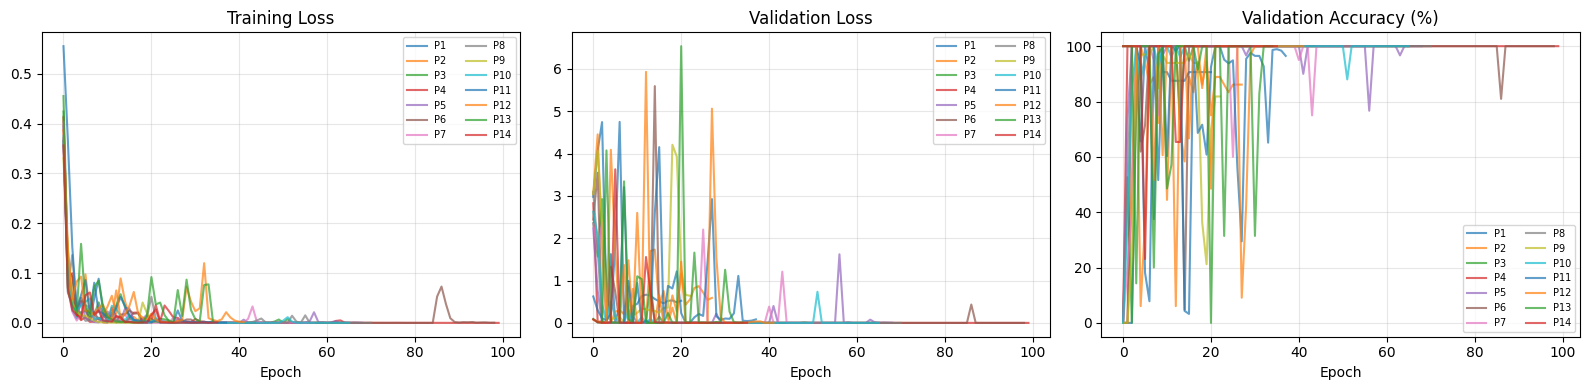

In [19]:
n_folds = len(results["histories"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, hist in enumerate(results["histories"]):
    p = results["participant"][i]
    axes[0].plot(hist["train_loss"], alpha=0.7, label=f"P{p}")
    axes[1].plot(hist["val_loss"], alpha=0.7, label=f"P{p}")
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.7, label=f"P{p}")

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

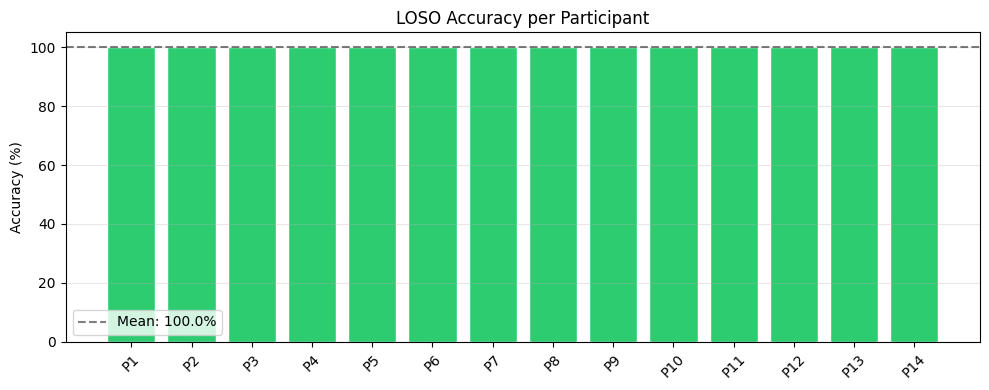

In [20]:
# Per-participant accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 4))

participants_sorted = sorted(zip(results["participant"], results["acc"]),
                             key=lambda x: x[1], reverse=True)
ps, accs = zip(*participants_sorted)
colors = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.6 else "#e74c3c"
          for a in accs]

ax.bar(range(len(ps)), [a * 100 for a in accs], color=colors, edgecolor="white")
ax.set_xticks(range(len(ps)))
ax.set_xticklabels([f"P{p}" for p in ps], rotation=45)
ax.set_ylabel("Accuracy (%)")
ax.set_title("LOSO Accuracy per Participant")
ax.axhline(y=np.mean(results["acc"]) * 100, color="black",
           linestyle="--", alpha=0.5, label=f"Mean: {np.mean(results['acc'])*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 9. LOSO Confusion Matrix (Aggregated)

In [21]:
# Use predictions already collected during LOSO (no retraining needed)
all_y_true = np.array(results["all_y_true"])
all_y_pred = np.array(results["all_y_pred"])

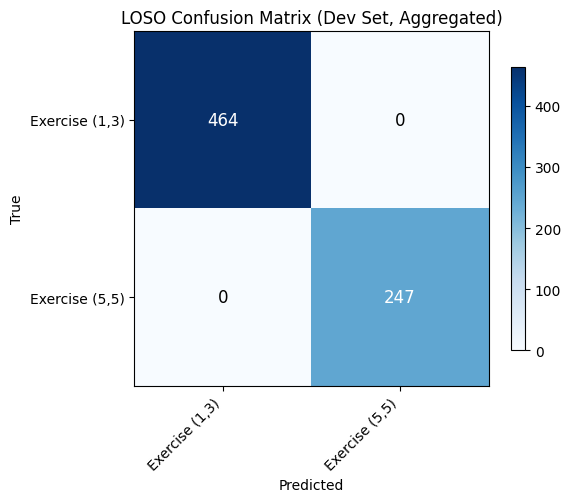


Classification Report:
                precision    recall  f1-score   support

Exercise (1,3)     1.0000    1.0000    1.0000       464
Exercise (5,5)     1.0000    1.0000    1.0000       247

      accuracy                         1.0000       711
     macro avg     1.0000    1.0000    1.0000       711
  weighted avg     1.0000    1.0000    1.0000       711



In [22]:
# Plot confusion matrix
class_names = ["Exercise (1,3)", "Exercise (5,5)"]
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=12)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("LOSO Confusion Matrix (Dev Set, Aggregated)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred,
                            target_names=class_names, digits=4))

---
## 10. Final Test Evaluation on OurData

Train on **all dev participants** (lean + myogym) using the **best hyperparameters
from the sweep**, then evaluate on **all 10 exercise pairs** from
`OurData_v5_scaled_20Hz.csv`.

The normalizer fitted on training data is applied (`transform_normalize`) to
OurData -- it is **not** re-fitted -- to prevent data leakage.
Results are reported per-exercise and per-parent-class.


In [32]:
print(f"Training on all dev data ({X_dev.shape[0]} windows, lean + myogym)...")
print(f"Using best config: lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")

# Build and train on all dev data (no early stopping -- full best_epochs)
test_model = CNN_LSTM(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
).to(DEVICE)

optimizer = torch.optim.Adam(test_model.parameters(), lr=best_lr)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

X_dev_t = torch.FloatTensor(X_dev).to(DEVICE)
y_dev_t = torch.LongTensor(y_dev).to(DEVICE)
train_dl = DataLoader(TensorDataset(X_dev_t, y_dev_t),
                      batch_size=best_batch_size, shuffle=True)

test_model.train()
for epoch in range(best_epochs):
    total_loss, n = 0.0, 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(test_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1
    avg_loss = total_loss / n
    scheduler.step(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}  loss={avg_loss:.4f}  "
              f"lr={optimizer.param_groups[0]['lr']:.1e}")

# -- Load and preprocess OurData --
print("\nLoading OurData_v5_scaled_20Hz.csv...")
df_ourdata_full = pd.read_csv(FULL_OUR_DATA_PATH)
print(f"  {df_ourdata_full.shape[0]:,} rows, participants: "
      f"{sorted(df_ourdata_full['participant'].unique())}")

# Keep all 10 test pairs and label by parent class
pair_mask_od = pd.Series(False, index=df_ourdata_full.index)
for p, c in TEST_PAIRS:
    pair_mask_od |= (df_ourdata_full["parent"] == p) & (df_ourdata_full["child"] == c)
df_ourdata_filt = df_ourdata_full[pair_mask_od].copy().reset_index(drop=True)
df_ourdata_filt["label"]    = df_ourdata_filt["parent"].map(LABEL_MAP)
df_ourdata_filt["pair_int"] = df_ourdata_filt.apply(
    lambda r: PAIR_TO_INT[(int(r["parent"]), int(r["child"]))], axis=1
)

print(f"  After filtering to test pairs: {len(df_ourdata_filt):,} rows")
print(f"\nPer-pair row counts:")
for p, c in TEST_PAIRS:
    n = ((df_ourdata_filt["parent"] == p) & (df_ourdata_filt["child"] == c)).sum()
    print(f"  ({p},{c:2d})  {PARENT_CLASSES[p]:<14s}  label={LABEL_MAP[p]}  ->  {n:,} rows")

# Preprocess: denoise + normalize using TRAINING fit (do NOT re-fit)
print("\nPreprocessing OurData (using training normalizer)...")
imu_denoised_od = pp.denoise(df_ourdata_filt[IMU_COLS].values)
df_ourdata_proc = df_ourdata_filt.copy()
df_ourdata_proc[IMU_COLS] = imu_denoised_od
df_ourdata_proc[IMU_COLS] = pp.transform_normalize(df_ourdata_proc[IMU_COLS].values)

# Segment -- parent-class labels (for accuracy)
X_test, y_test, _ = pp.segment_by_id(df_ourdata_proc, IMU_COLS)

# Segment -- pair_int labels (for per-exercise breakdown)
_, pair_int_test, _ = pp.segment_by_id(df_ourdata_proc, IMU_COLS, label_col="pair_int")
pairs_test = np.array([INT_TO_PAIR[i] for i in pair_int_test])  # shape (N, 2)

print(f"\nTest windows: {X_test.shape}")
print(f"  Label 0 (Arm Curl):    {(y_test == 0).sum()} windows")
print(f"  Label 1 (Bench Press): {(y_test == 1).sum()} windows")


Training on all dev data (711 windows, lean + myogym)...
Using best config: lr=0.001, batch_size=32, epochs=100, patience=15
  Epoch  10  loss=0.0112  lr=1.0e-03
  Epoch  20  loss=0.0016  lr=5.0e-04
  Epoch  30  loss=0.0003  lr=5.0e-04
  Epoch  40  loss=0.0122  lr=5.0e-04
  Epoch  50  loss=0.0032  lr=1.3e-04
  Epoch  60  loss=0.0071  lr=6.3e-05
  Epoch  70  loss=0.0065  lr=1.6e-05
  Epoch  80  loss=0.0008  lr=3.9e-06
  Epoch  90  loss=0.0030  lr=2.0e-06
  Epoch 100  loss=0.0024  lr=1.0e-06

Loading OurData_v5_scaled_20Hz.csv...
  52,828 rows, participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
  After filtering to test pairs: 52,828 rows

Per-pair row counts:
  (1, 1)  Arm Curl        label=0  ->  5,273 rows
  (1, 2)  Arm Curl        label=0  ->  5,595 rows
  (1, 3)  Arm Curl        label=0  ->  5,535 rows
  (1, 4)  Arm Curl        label=0  ->  5,697 rows
  (5, 5)  Bench Press     label=1  ->  4,356 rows
  (5, 6)  Bench Press     label=1  ->  5,247 rows

In [33]:
# -- Run inference --
test_model.eval()
with torch.no_grad():
    y_pred_test = test_model(
        torch.FloatTensor(X_test).to(DEVICE)
    ).argmax(1).cpu().numpy()
y_true_test = y_test

overall_acc  = accuracy_score(y_true_test, y_pred_test) * 100
overall_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0) * 100
overall_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0) * 100
overall_f1   = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0) * 100

print(f"{'='*60}")
print(f"OVERALL TEST RESULTS (OurData -- all 10 exercises)")
print(f"{'='*60}")
print(f"  Accuracy:  {overall_acc:.2f}%")
print(f"  Precision: {overall_prec:.2f}%  (macro)")
print(f"  Recall:    {overall_rec:.2f}%  (macro)")
print(f"  F1-score:  {overall_f1:.2f}%  (macro)")

# -- Per-exercise breakdown --
print("\n\nPer-Exercise Results (OurData test set)")
print("=" * 72)
print(f"  {'Exercise':>10s}  {'Parent Class':>14s}  {'Windows':>8s}  {'Acc (%)':>8s}  {'F1 (%)':>8s}")
print("-" * 72)

ex_rows = []
for p, c in TEST_PAIRS:
    mask = (pairs_test[:, 0] == p) & (pairs_test[:, 1] == c)
    if mask.sum() == 0:
        continue
    yt  = y_true_test[mask]
    yp  = y_pred_test[mask]
    acc = accuracy_score(yt, yp) * 100
    f1  = f1_score(yt, yp, average="binary",
                   pos_label=LABEL_MAP[p], zero_division=0) * 100
    parent_name = PARENT_CLASSES[p]
    n = int(mask.sum())
    print(f"  ({p},{c:2d})        {parent_name:>14s}  {n:>8d}  {acc:>8.2f}  {f1:>8.2f}")
    ex_rows.append({
        "Exercise": f"({p},{c})",
        "Parent Class": parent_name,
        "Windows": n,
        "Acc (%)": round(acc, 2),
        "F1 (%)": round(f1, 2),
    })

ex_df = pd.DataFrame(ex_rows)
print("\nPer-Exercise Table:")
display(ex_df)

# -- Per-parent-class aggregate --
print("\nPer-Parent-Class Aggregate Results (OurData)")
print("=" * 50)
for parent_val, parent_name in PARENT_CLASSES.items():
    label = LABEL_MAP[parent_val]
    mask  = pairs_test[:, 0] == parent_val
    yt    = y_true_test[mask]
    yp    = y_pred_test[mask]
    acc   = accuracy_score(yt, yp) * 100
    f1    = f1_score(yt, yp, average="binary", pos_label=label, zero_division=0) * 100
    print(f"  {parent_name:<14s}  Acc={acc:.2f}%  F1={f1:.2f}%  ({mask.sum()} windows)")


OVERALL TEST RESULTS (OurData -- all 10 exercises)
  Accuracy:  85.80%
  Precision: 86.21%  (macro)
  Recall:    84.56%  (macro)
  F1-score:  85.13%  (macro)


Per-Exercise Results (OurData test set)
    Exercise    Parent Class   Windows   Acc (%)    F1 (%)
------------------------------------------------------------------------
  (1, 1)              Arm Curl       251     84.06     91.34
  (1, 2)              Arm Curl       264     99.24     99.62
  (1, 3)              Arm Curl       261     88.89     94.12
  (1, 4)              Arm Curl       270     36.67     53.66
  (5, 5)           Bench Press       204     92.65     96.18
  (5, 6)           Bench Press       247     92.71     96.22
  (5, 7)           Bench Press       210     82.86     90.62
  (5, 8)           Bench Press       266     95.11     97.50
  (5, 9)           Bench Press       257     94.55     97.20
  (5,10)           Bench Press       263     93.92     96.86

Per-Exercise Table:


,Exercise,Parent Class,Windows,Acc (%),F1 (%)
0,"(1,1)",Arm Curl,251,84.06,91.34
1,"(1,2)",Arm Curl,264,99.24,99.62
2,"(1,3)",Arm Curl,261,88.89,94.12
3,"(1,4)",Arm Curl,270,36.67,53.66
4,"(5,5)",Bench Press,204,92.65,96.18
5,"(5,6)",Bench Press,247,92.71,96.22
6,"(5,7)",Bench Press,210,82.86,90.62
7,"(5,8)",Bench Press,266,95.11,97.50
8,"(5,9)",Bench Press,257,94.55,97.20
9,"(5,10)",Bench Press,263,93.92,96.86



Per-Parent-Class Aggregate Results (OurData)
  Arm Curl        Acc=76.86%  F1=86.92%  (1046 windows)
  Bench Press     Acc=92.26%  F1=95.97%  (1447 windows)


---
## 11. Save / Load Model

In [34]:
# Save the model trained on all dev data
save_path = os.path.join(BASE_PATH, "cnn_lstm_crossdataset_imu.pt")
torch.save(test_model.state_dict(), save_path)
print(f"Model saved to: {save_path}")


Model saved to: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/cnn_lstm_crossdataset_imu.pt


In [35]:
# Load for inference
loaded_model = CNN_LSTM(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
).to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path, map_location=DEVICE))
loaded_model.eval()

# Predict on a single window
sample = torch.FloatTensor(X_test[:1]).to(DEVICE)
with torch.no_grad():
    logits = loaded_model(sample)
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()

label_names = {0: "Arm Curl", 1: "Bench Press"}
print(f"Predicted: {label_names[pred]}")
print(f"Probabilities: {dict(zip(label_names.values(), probs[0].cpu().numpy().round(4)))}")


Predicted: Bench Press
Probabilities: {'Arm Curl': np.float32(0.3752), 'Bench Press': np.float32(0.6248)}


---
## 12. Visual Inspection: Ground Truth vs Predictions (LOSO)

In [36]:
# ============================================================
# Visual Inspection: Ground Truth vs Predictions (LOSO)
# ============================================================

# Rebuild per-fold predictions with fold boundaries
logo = LeaveOneGroupOut()
fold_data = []

for fold, (tr_idx, va_idx) in enumerate(logo.split(X_dev, y_dev, participants_dev)):
    held_out = participants_dev[va_idx[0]]

    model = CNN_LSTM(in_channels=X_dev.shape[2], num_classes=NUM_CLASSES).to(DEVICE)
    model, _ = train_one_fold(
        model, X_dev[tr_idx], y_dev[tr_idx], X_dev[va_idx], y_dev[va_idx],
        device=DEVICE, epochs=EPOCHS, batch_size=BATCH_SIZE,
        lr=LEARNING_RATE, patience=PATIENCE, verbose=False,
    )
    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_dev[va_idx]).to(DEVICE)).argmax(1).cpu().numpy()

    fold_data.append({
        "participant": held_out,
        "y_true": y_dev[va_idx],
        "y_pred": preds,
    })
    print(f"  Fold {fold+1} done (participant {held_out})")

  Fold 1 done (participant 1)
  Fold 2 done (participant 2)
  Fold 3 done (participant 3)
  Fold 4 done (participant 4)
  Fold 5 done (participant 5)
  Fold 6 done (participant 6)
  Fold 7 done (participant 7)
  Fold 8 done (participant 8)
  Fold 9 done (participant 9)
  Fold 10 done (participant 10)
  Fold 11 done (participant 11)
  Fold 12 done (participant 12)
  Fold 13 done (participant 13)
  Fold 14 done (participant 14)


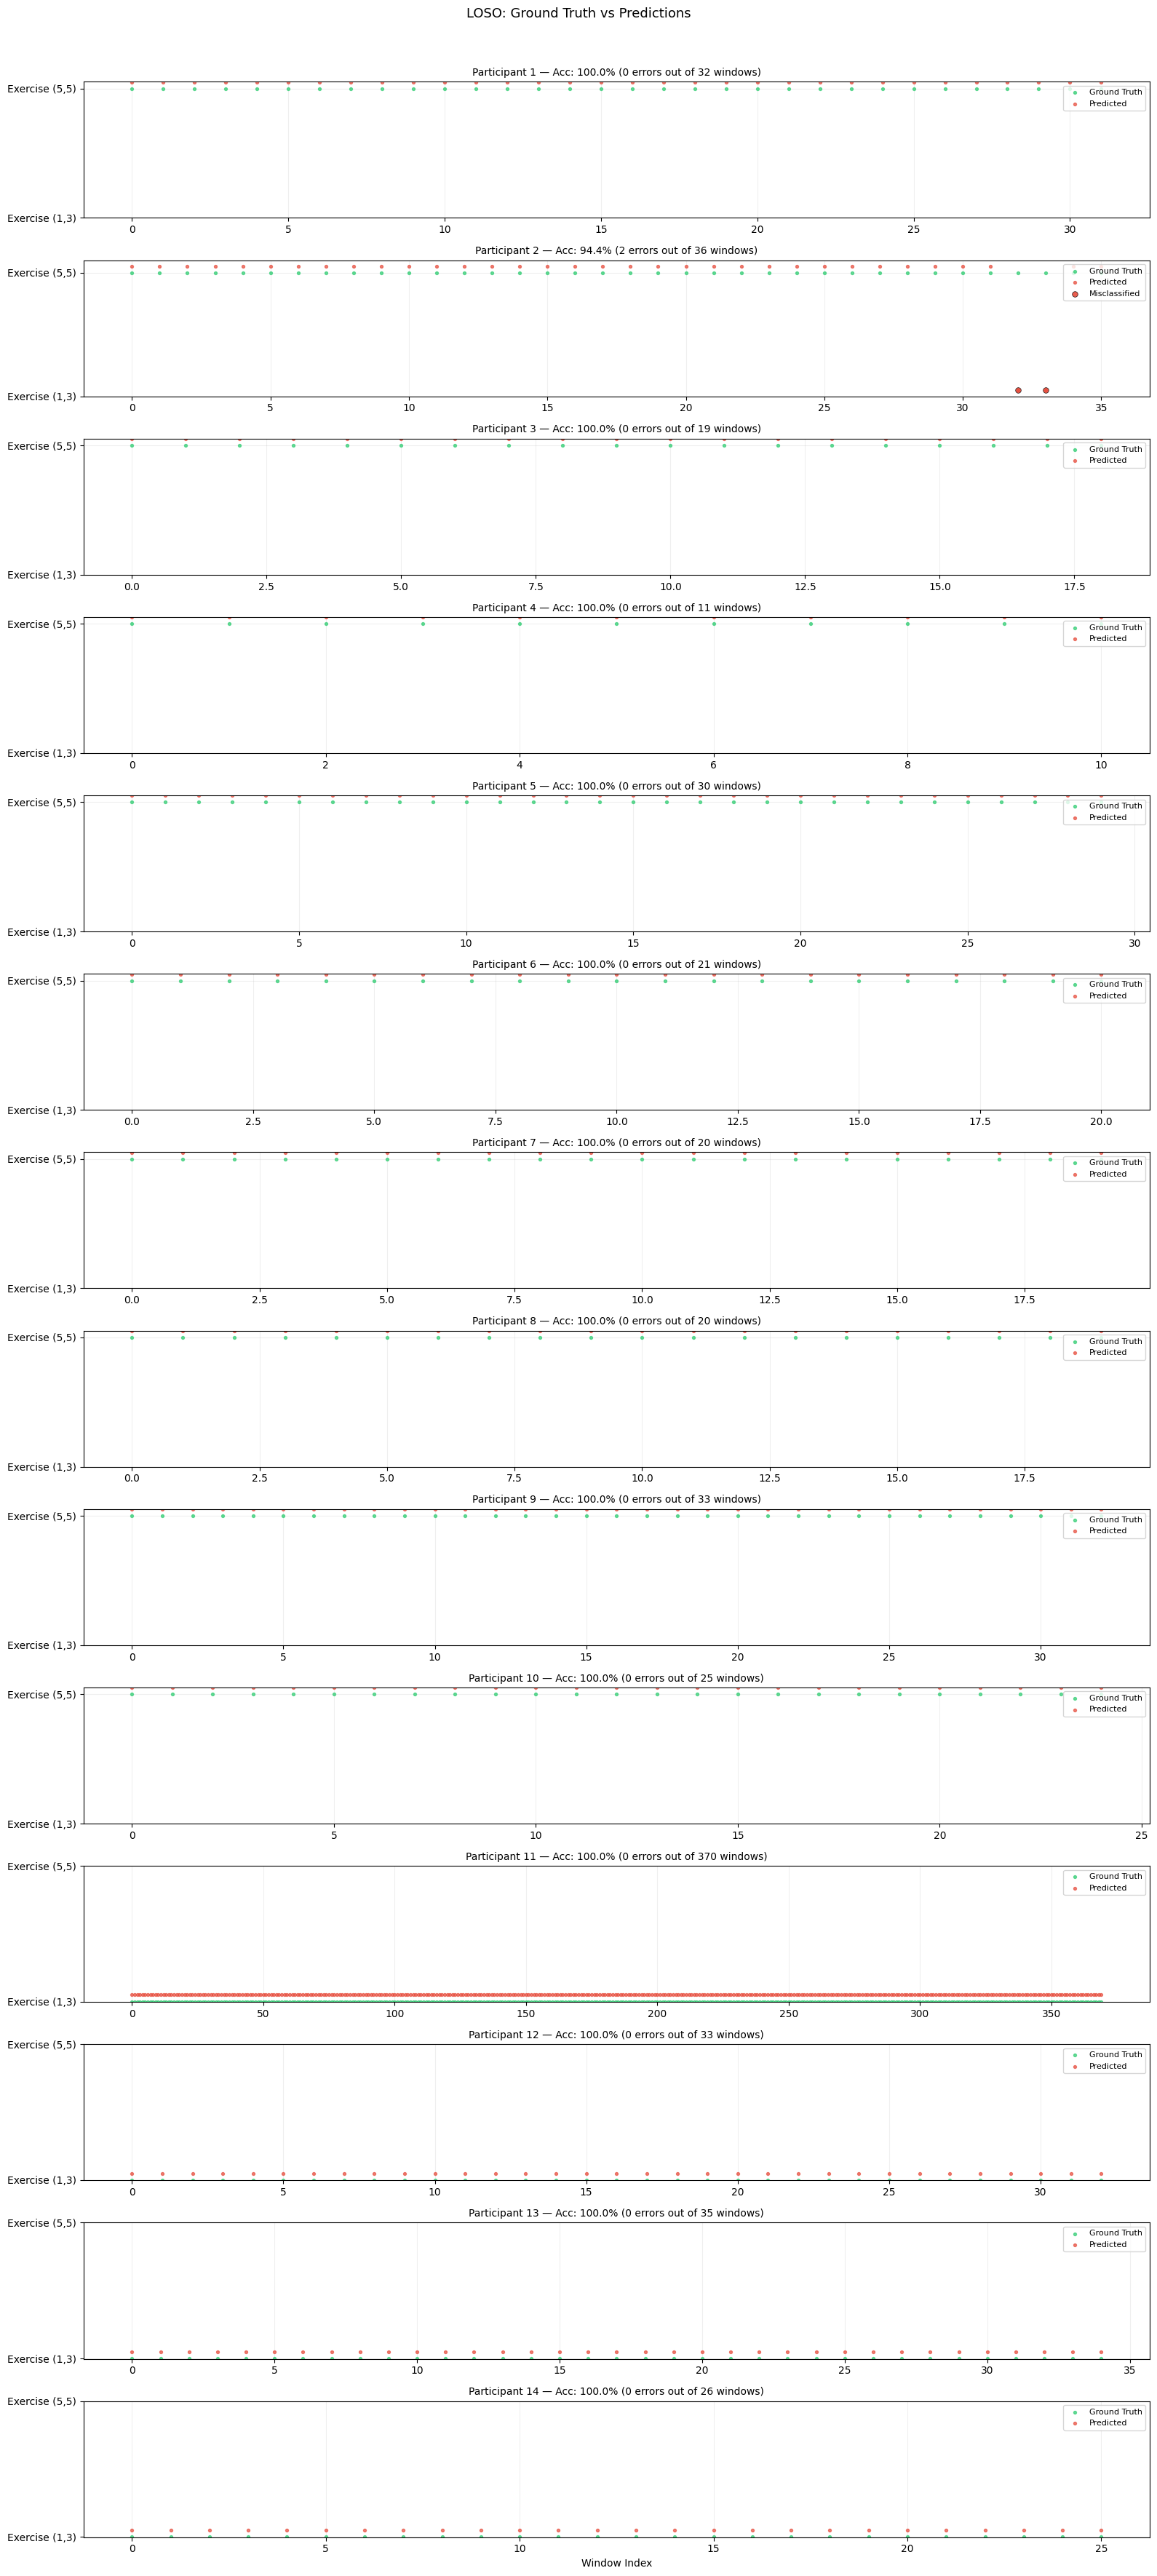

In [37]:
n_folds = len(fold_data)
fig, axes = plt.subplots(n_folds, 1, figsize=(16, 2.5 * n_folds), sharex=False)
if n_folds == 1:
    axes = [axes]

for ax, fd in zip(axes, fold_data):
    windows = np.arange(len(fd["y_true"]))

    # Plot ground truth and predictions slightly offset so both are visible
    ax.scatter(windows, fd["y_true"], c="#2ecc71", s=8, alpha=0.7, label="Ground Truth", zorder=2)
    ax.scatter(windows, fd["y_pred"] + 0.05, c="#e74c3c", s=8, alpha=0.7, label="Predicted", zorder=2)

    # Highlight mismatches
    mismatches = fd["y_true"] != fd["y_pred"]
    if mismatches.any():
        ax.scatter(windows[mismatches], fd["y_pred"][mismatches] + 0.05,
                   c="#e74c3c", s=30, edgecolors="black", linewidths=0.5,
                   alpha=0.9, zorder=3, label="Misclassified")

    acc = accuracy_score(fd["y_true"], fd["y_pred"])
    n_wrong = mismatches.sum()
    ax.set_title(f"Participant {fd['participant']} — Acc: {acc*100:.1f}% "
                 f"({n_wrong} errors out of {len(fd['y_true'])} windows)", fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Exercise (1,3)", "Exercise (5,5)"])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Window Index")
fig.suptitle("LOSO: Ground Truth vs Predictions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

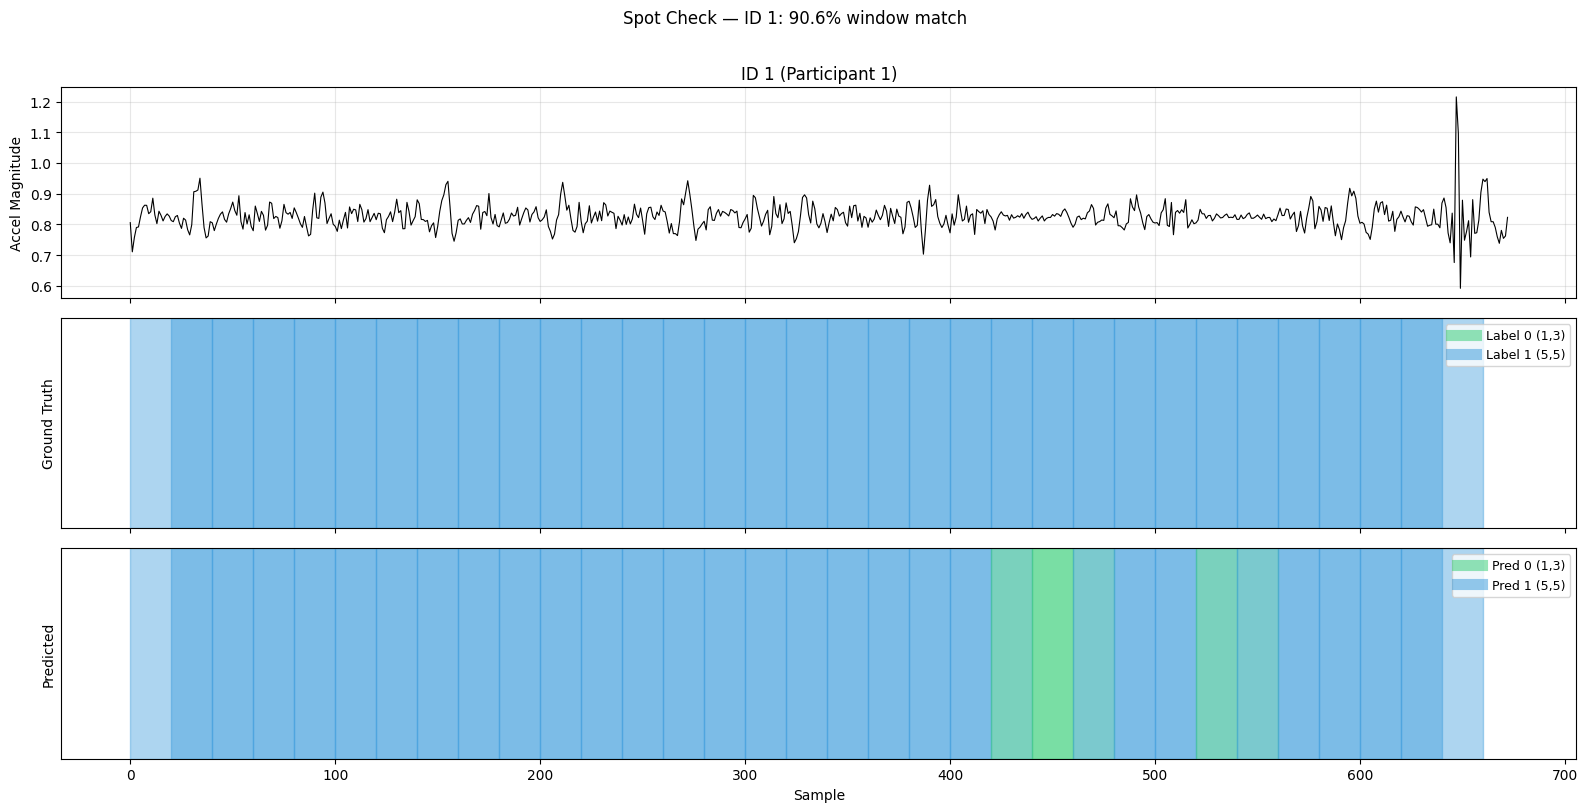

In [38]:
# Pick a random ID from the dev set to spot-check
spot_participant = fold_data[0]["participant"]
spot_ids = df_processed[df_processed["participant"] == spot_participant]["ID"].unique()
spot_id = spot_ids[0]

spot_df = df_processed[df_processed["ID"] == spot_id].reset_index(drop=True)
spot_imu = spot_df[IMU_COLS].values
spot_labels = spot_df["label"].values

# Get model predictions for this ID's windows
spot_windows, spot_wlabels = pp.segment_single(spot_imu, spot_labels)
spot_X = np.array(spot_windows, dtype=np.float32)
spot_y = np.array(spot_wlabels, dtype=np.int64)

model.eval()
with torch.no_grad():
    spot_preds = model(torch.FloatTensor(spot_X).to(DEVICE)).argmax(1).cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

# Plot raw accelerometer magnitude
accel_mag = np.sqrt(spot_imu[:, 0]**2 + spot_imu[:, 1]**2 + spot_imu[:, 2]**2)
axes[0].plot(accel_mag, color="black", linewidth=0.8)
axes[0].set_ylabel("Accel Magnitude")
axes[0].set_title(f"ID {spot_id} (Participant {spot_participant})")
axes[0].grid(True, alpha=0.3)

# Plot ground truth as colored regions
colors_map = {0: "#2ecc71", 1: "#3498db"}
label_names_short = {0: "(1,3)", 1: "(5,5)"}

for i, lbl in enumerate(spot_y):
    start = i * pp.step_size
    end = start + pp.window_size
    axes[1].axvspan(start, end, alpha=0.4, color=colors_map[lbl])
axes[1].set_ylabel("Ground Truth")
axes[1].set_yticks([])
# Manual legend
for lbl, color in colors_map.items():
    axes[1].plot([], [], color=color, linewidth=8, alpha=0.5,
                 label=f"Label {lbl} {label_names_short[lbl]}")
axes[1].legend(loc="upper right", fontsize=9)

# Plot predictions as colored regions
for i, pred in enumerate(spot_preds):
    start = i * pp.step_size
    end = start + pp.window_size
    axes[2].axvspan(start, end, alpha=0.4, color=colors_map[pred])
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Sample")
axes[2].set_yticks([])
for lbl, color in colors_map.items():
    axes[2].plot([], [], color=color, linewidth=8, alpha=0.5,
                 label=f"Pred {lbl} {label_names_short[lbl]}")
axes[2].legend(loc="upper right", fontsize=9)

match_pct = (spot_y == spot_preds).mean() * 100
fig.suptitle(f"Spot Check — ID {spot_id}: {match_pct:.1f}% window match", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 13. Test Results Charts

Confusion matrix and per-exercise bar charts for the OurData test set.


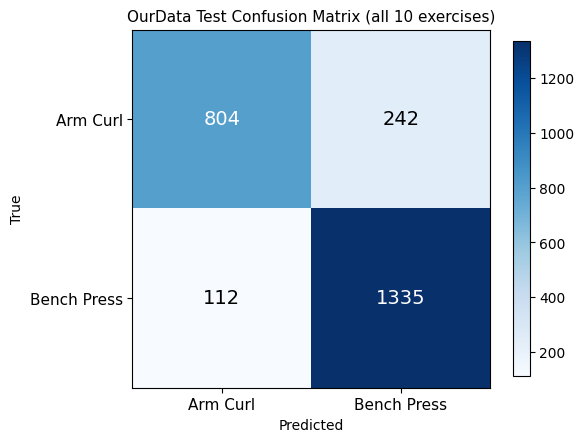


Test Classification Report (OurData):
              precision    recall  f1-score   support

    Arm Curl     0.8777    0.7686    0.8196      1046
 Bench Press     0.8465    0.9226    0.8829      1447

    accuracy                         0.8580      2493
   macro avg     0.8621    0.8456    0.8513      2493
weighted avg     0.8596    0.8580    0.8564      2493



In [39]:
# Confusion matrix on OurData test set
cm_test = confusion_matrix(y_true_test, y_pred_test)
class_names_test = ["Arm Curl", "Bench Press"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_test, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names_test, fontsize=11)
ax.set_yticklabels(class_names_test, fontsize=11)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_test[i, j]}", ha="center", va="center",
                color="white" if cm_test[i, j] > cm_test.max() / 2 else "black",
                fontsize=14)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("OurData Test Confusion Matrix (all 10 exercises)", fontsize=11)
plt.tight_layout()
plt.show()

print("\nTest Classification Report (OurData):")
print(classification_report(y_true_test, y_pred_test,
                            target_names=class_names_test, digits=4))


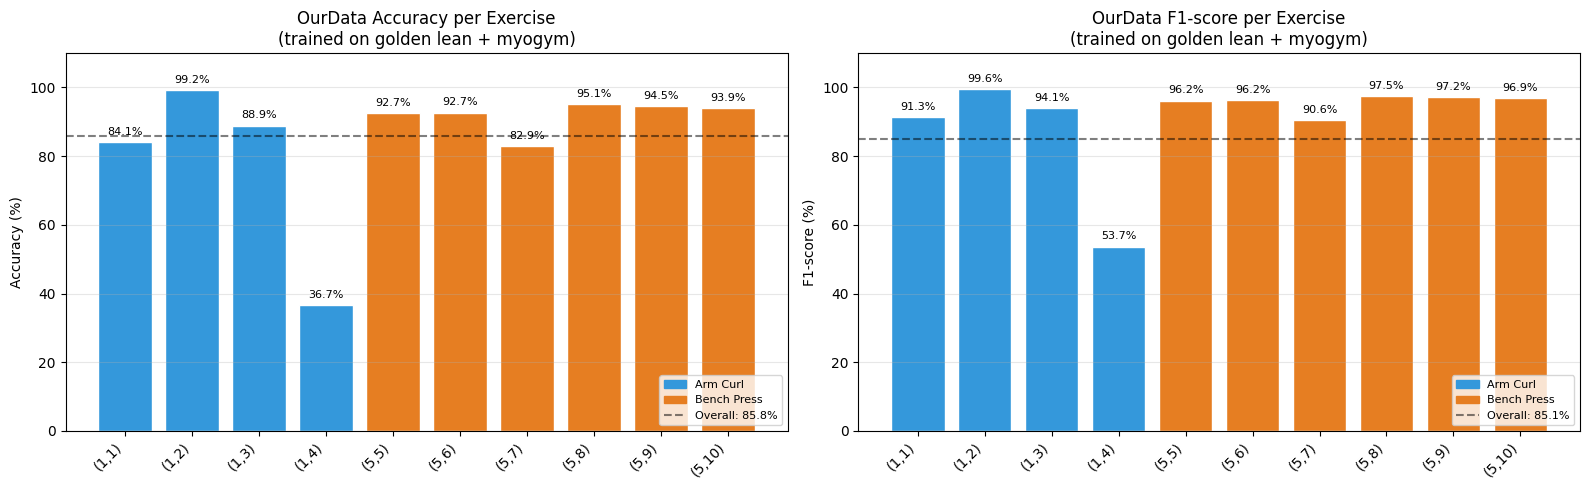

In [40]:
# Per-exercise accuracy and F1 bar charts
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ex_names   = ex_df["Exercise"].tolist()
ex_accs    = ex_df["Acc (%)"].tolist()
ex_f1s     = ex_df["F1 (%)"].tolist()
ex_parents = ex_df["Parent Class"].tolist()
colors = ["#3498db" if p == "Arm Curl" else "#e67e22" for p in ex_parents]

for ax, vals, metric in zip(axes, [ex_accs, ex_f1s], ["Accuracy", "F1-score"]):
    overall = overall_acc if metric == "Accuracy" else overall_f1
    bars = ax.bar(range(len(ex_names)), vals, color=colors, edgecolor="white")
    ax.set_xticks(range(len(ex_names)))
    ax.set_xticklabels(ex_names, rotation=45, ha="right")
    ax.set_ylabel(f"{metric} (%)")
    ax.set_title(f"OurData {metric} per Exercise\n(trained on golden lean + myogym)")
    ax.axhline(y=overall, color="black", linestyle="--", alpha=0.5,
               label=f"Overall: {overall:.1f}%")
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.legend(handles=[
        Patch(color="#3498db", label="Arm Curl"),
        Patch(color="#e67e22", label="Bench Press"),
        ax.get_lines()[0],
    ], loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()
